# Cybersecurity: Advanced AI-Powered

> AI is significantly enhancing cybersecurity by enabling advanced threat detection, incident response, and proactive defense strategies. AI-powered systems can analyze vast amounts of data to identify anomalies, predict vulnerabilities, and automate security tasks, making it more efficient and effective at protecting systems. 

**Here's a more detailed look at how AI is being used in cybersecurity:**

- Threat Detection:
- Real-time monitoring:
AI can analyze network traffic and system behavior in real-time, identifying suspicious patterns and anomalies that might indicate a cyberattack. 
- Vulnerability identification:
AI models can analyze data to detect security weaknesses, predict potential threats, and recommend remediation strategies. 
- Predictive threat intelligence:
AI can analyze historical data to predict potential threats and vulnerabilities, allowing organizations to take proactive measures. 
- Incident Response:
- Automated triage and prioritization:
AI can automatically categorize and prioritize security alerts, helping security teams focus on the most critical threats. 
- Rapid threat containment:
AI-powered solutions can automatically isolate infected endpoints or terminate malicious processes, preventing the spread of an attack. 
- Context-aware alerts:
AI can provide context-aware alerts, enriching alerts with information that helps security teams understand the nature of the threat and respond more effectively.    ---- Proactive Defense:
- User behavior analytics (UBA):
AI can analyze user behavior to detect insider threats and compromised accounts. 
- Data loss prevention (DLP):
AI can monitor and protect sensitive data from unauthorized access and breaches. 
- Security automation:
AI can automate security tasks, such as vulnerability scanning, patch management, and security configuration, freeing up security teams to focus on more strategic activities. 
- Examples of AI-powered cybersecurity solutions:
- Palo Alto Networks Cortex XDR:
A holistic XDR solution that uses AI to detect, investigate, and respond to threats across networks, endpoints, and cloud environments. 
- Vectra AI:
A platform that focuses on detecting known and unknown threats across various environments using behavior-based analysis and threat intelligence. 
- CrowdStrike Falcon:
An EDR solution that monitors endpoint activity, analyzes behavior baselines, and alerts security teams in real-time. 
- Benefits of AI in Cybersecurity:
- Improved threat detection:
AI can identify threats more quickly and accurately than traditional methods. 
- Faster incident response:
AI can automate incident response, reducing the time it takes to contain a breach. 
- Proactive defense:
AI can help organizations identify and mitigate vulnerabilities before they are exploited. 
- Reduced alert fatigue:
AI can help filter out irrelevant alerts, focusing security teams on the most important threats. 
- Increased efficiency:
AI can automate security tasks, freeing up security teams to focus on more strategic activities. 

# Project Overview

> This project leverages advanced machine learning techniques to classify web traffic anomalies and provide automated response strategies. By analyzing VPC flow data, we aim to enhance cybersecurity measures for cloud-based systems.

# Introduction

This project focuses on:

- Detecting web traffic anomalies.
- Classifying attack types (e.g., DDoS, SQL Injection).
- Proposing intelligent response strategies.

# Project Objectives

- Threat Detection: Identify suspicious patterns in web traffic.
- Attack Classification: Categorize traffic anomalies into specific attack types.
- Response Recommendation: Suggest automated defense strategies for identified threats.

 # Importing Required Libraries

In [1]:
import pandas as pd   
import numpy as np    
import matplotlib.pyplot as plt  
import seaborn as sns            
import plotly.express as px      
import plotly.graph_objects as go   

from sklearn.model_selection import train_test_split  
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder   
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix   
from datetime import datetime  # Timestamp handling
import warnings
warnings.filterwarnings('ignore')   
try:
    import ipywidgets as widgets  # Interactive widgets for Jupyter notebooks
except ImportError:
  print("Optional library 'ipywidgets' not installed. Install via 'pip install ipywidgets' if required.")
print("✔️Libraries successfully imported. Ready to proceed!")

✔️Libraries successfully imported. Ready to proceed!


# Importing and Exploring the Dataset

In [2]:
file_path = '/kaggle/input/ai-cyber-threat-detector/cleaned_featured_data.csv'

In [3]:
try:
    df = pd.read_csv(file_path)
    print("✔️ Dataset successfully loaded!")
except FileNotFoundError:
    print(f"❌ File not found at {file_path}. Please check the file path and try again.")

✔️ Dataset successfully loaded!


In [4]:
print(f'✔️The shape of the data is: {df.shape}\n')
print(f'✔️The size of the data is: {df.size}\n')


✔️The shape of the data is: (282, 16)

✔️The size of the data is: 4512



In [5]:
df.describe(include='object')

,creation_time,end_time,src_ip,src_ip_country_code,protocol,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
count,282,282,282,282,282,282,282,282,282,282,282,282
unique,30,30,28,7,1,1,1,1,1,1,30,1
top,2024-04-26 09:00:00+00:00,2024-04-26 09:10:00+00:00,165.225.209.4,US,HTTPS,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 09:00:00+00:00,waf_rule
freq,17,17,29,113,282,282,282,282,282,282,17,282


In [6]:
print(f'✔️The shape of the data is: {df.info}\n')
print(f'✔️The columns in the dataset are: \n {df.columns}')

✔️The shape of the data is: <bound method DataFrame.info of                  creation_time                   end_time           src_ip  \
0    2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   147.161.161.82   
1    2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00     165.225.33.6   
2    2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00  165.225.212.255   
3    2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   136.226.64.114   
4    2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   165.225.240.79   
..                         ...                        ...              ...   
277  2024-04-26 09:50:00+00:00  2024-04-26 10:00:00+00:00   136.226.77.103   
278  2024-04-26 09:50:00+00:00  2024-04-26 10:00:00+00:00   165.225.26.101   
279  2024-04-26 09:50:00+00:00  2024-04-26 10:00:00+00:00    155.91.45.242   
280  2024-04-26 09:50:00+00:00  2024-04-26 10:00:00+00:00    165.225.209.4   
281  2024-04-26 09:50:00+00:00  2024-04-26 10:00:00+00:00    147.161.131.1   

   

In [7]:
if df.duplicated().any()>0:
    print(f"✔️The number of duplicates are {df.duplicated().sum()}")
else:
    print(f'✔️There are no duplicates r in the dataset')

✔️There are no duplicates r in the dataset


In [8]:
df.tail()
display(df.tail().style.background_gradient(cmap='Blues'))

,creation_time,end_time,src_ip,src_ip_country_code,protocol,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types,traffic_intensity_log,bytes_in_log,src_ip_encoded,src_ip_country_code_encoded
277,2024-04-26 09:50:00+00:00,2024-04-26 10:00:00+00:00,136.226.77.103,CA,HTTPS,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 09:50:00+00:00,waf_rule,0.434986,0.001637,2,2
278,2024-04-26 09:50:00+00:00,2024-04-26 10:00:00+00:00,165.225.26.101,DE,HTTPS,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 09:50:00+00:00,waf_rule,0.342004,0.000143,11,3
279,2024-04-26 09:50:00+00:00,2024-04-26 10:00:00+00:00,155.91.45.242,US,HTTPS,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 09:50:00+00:00,waf_rule,1.098612,0.693147,6,6
280,2024-04-26 09:50:00+00:00,2024-04-26 10:00:00+00:00,165.225.209.4,CA,HTTPS,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 09:50:00+00:00,waf_rule,0.428832,0.000226,7,2
281,2024-04-26 09:50:00+00:00,2024-04-26 10:00:00+00:00,147.161.131.1,AT,HTTPS,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 09:50:00+00:00,waf_rule,0.382653,0.000357,4,1


In [9]:
print(df.ndim) 

2


In [10]:
print("\n☑️ First 5 Rows:")
print(df.head())


☑️ First 5 Rows:
               creation_time                   end_time           src_ip  \
0  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   147.161.161.82   
1  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00     165.225.33.6   
2  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00  165.225.212.255   
3  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   136.226.64.114   
4  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   165.225.240.79   

  src_ip_country_code protocol        dst_ip              rule_names  \
0                  AE    HTTPS  10.138.69.97  Suspicious Web Traffic   
1                  US    HTTPS  10.138.69.97  Suspicious Web Traffic   
2                  CA    HTTPS  10.138.69.97  Suspicious Web Traffic   
3                  US    HTTPS  10.138.69.97  Suspicious Web Traffic   
4                  NL    HTTPS  10.138.69.97  Suspicious Web Traffic   

                       observation_name   source.meta     source.name  \
0  Adversary Infras

In [11]:
print("\n🛡️ Dataset Statistics:")
print(df.describe(include='all'))


🛡️ Dataset Statistics:
                    creation_time                   end_time         src_ip  \
count                         282                        282            282   
unique                         30                         30             28   
top     2024-04-26 09:00:00+00:00  2024-04-26 09:10:00+00:00  165.225.209.4   
freq                           17                         17             29   
mean                          NaN                        NaN            NaN   
std                           NaN                        NaN            NaN   
min                           NaN                        NaN            NaN   
25%                           NaN                        NaN            NaN   
50%                           NaN                        NaN            NaN   
75%                           NaN                        NaN            NaN   
max                           NaN                        NaN            NaN   

       src_ip_country_code 

# Missing Data Check and Homogeneity Testing

In [12]:
missing_data = df.isnull().sum()
print("\n✔️Missing Data Summary:")
print(missing_data[missing_data > 0])


✔️Missing Data Summary:
Series([], dtype: int64)


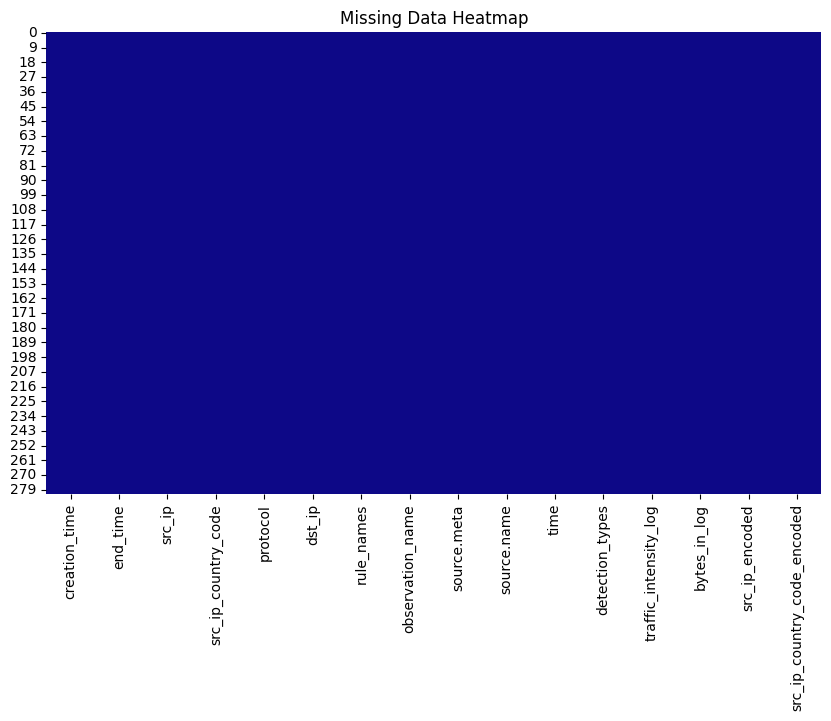

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='plasma')
plt.title('Missing Data Heatmap')
plt.show()

In [14]:
# Importing necessary libraries for statistical tests
from scipy.stats import levene

In [15]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

In [16]:
print("\n✔️ Missing data handling and homogeneity testing completed!")


✔️ Missing data handling and homogeneity testing completed!


# Normalizing and Scaling Features

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

In [19]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

In [20]:
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [21]:
print("\n✅ Transformed Dataset (First 5 Rows):")
print(df.head())


✅ Transformed Dataset (First 5 Rows):
               creation_time                   end_time           src_ip  \
0  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   147.161.161.82   
1  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00     165.225.33.6   
2  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00  165.225.212.255   
3  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   136.226.64.114   
4  2024-04-25 23:00:00+00:00  2024-04-25 23:10:00+00:00   165.225.240.79   

  src_ip_country_code protocol        dst_ip              rule_names  \
0                  AE    HTTPS  10.138.69.97  Suspicious Web Traffic   
1                  US    HTTPS  10.138.69.97  Suspicious Web Traffic   
2                  CA    HTTPS  10.138.69.97  Suspicious Web Traffic   
3                  US    HTTPS  10.138.69.97  Suspicious Web Traffic   
4                  NL    HTTPS  10.138.69.97  Suspicious Web Traffic   

                       observation_name   source.meta     source.name  

In [22]:
# Check if the scaling was successful
print("\n☑️  Summary Statistics After Scaling:")
print(df[numerical_columns].describe())


☑️  Summary Statistics After Scaling:
       traffic_intensity_log  bytes_in_log  src_ip_encoded  \
count             282.000000    282.000000      282.000000   
mean                0.427761      0.054362        0.292882   
std                 0.134085      0.176540        0.238411   
min                 0.000000      0.000000        0.000000   
25%                 0.385522      0.000306        0.148148   
50%                 0.397812      0.000752        0.259259   
75%                 0.433389      0.001761        0.407407   
max                 1.000000      1.000000        1.000000   

       src_ip_country_code_encoded  
count                   282.000000  
mean                      0.634161  
std                       0.347315  
min                       0.000000  
25%                       0.333333  
50%                       0.666667  
75%                       1.000000  
max                       1.000000  


In [23]:
# Proceed to feature engineering or model training.
print("\n✔️ Features normalized and scaled successfully!")


✔️ Features normalized and scaled successfully!


# Advanced Data Exploration

In [24]:
# Summary statistics for all columns
print("\n✅ Complete Summary Statistics:")
print(df.describe(include='all'))


✅ Complete Summary Statistics:
                    creation_time                   end_time         src_ip  \
count                         282                        282            282   
unique                         30                         30             28   
top     2024-04-26 09:00:00+00:00  2024-04-26 09:10:00+00:00  165.225.209.4   
freq                           17                         17             29   
mean                          NaN                        NaN            NaN   
std                           NaN                        NaN            NaN   
min                           NaN                        NaN            NaN   
25%                           NaN                        NaN            NaN   
50%                           NaN                        NaN            NaN   
75%                           NaN                        NaN            NaN   
max                           NaN                        NaN            NaN   

       src_ip_count

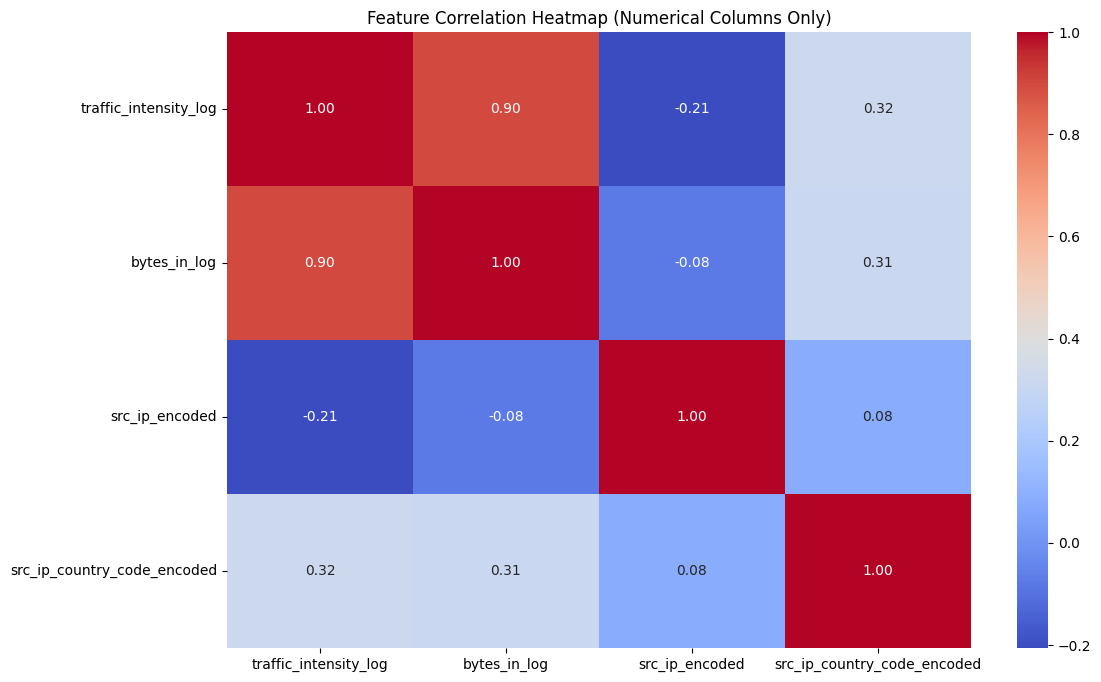

In [25]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_columns].corr()

# Visualizing the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap (Numerical Columns Only)')
plt.show()


✔️ Unique Values in creation_time:
creation_time
2024-04-26 09:00:00+00:00    17
2024-04-26 08:50:00+00:00    13
2024-04-26 09:50:00+00:00    11
2024-04-25 23:20:00+00:00    11
2024-04-26 09:40:00+00:00    11
2024-04-25 23:10:00+00:00    11
2024-04-26 00:40:00+00:00    10
2024-04-26 08:20:00+00:00    10
2024-04-26 01:20:00+00:00    10
2024-04-26 01:00:00+00:00    10
2024-04-25 23:00:00+00:00    10
2024-04-26 01:30:00+00:00    10
2024-04-26 00:10:00+00:00    10
2024-04-25 23:50:00+00:00     9
2024-04-26 01:10:00+00:00     9
2024-04-26 01:40:00+00:00     9
2024-04-26 09:30:00+00:00     9
2024-04-25 23:40:00+00:00     9
2024-04-26 00:30:00+00:00     9
2024-04-26 09:10:00+00:00     9
2024-04-25 23:30:00+00:00     8
2024-04-26 09:20:00+00:00     8
2024-04-26 00:00:00+00:00     8
2024-04-26 08:30:00+00:00     8
2024-04-26 01:50:00+00:00     8
2024-04-26 00:20:00+00:00     8
2024-04-26 08:40:00+00:00     7
2024-04-26 08:10:00+00:00     7
2024-04-26 08:00:00+00:00     7
2024-04-26 00:50:00+00

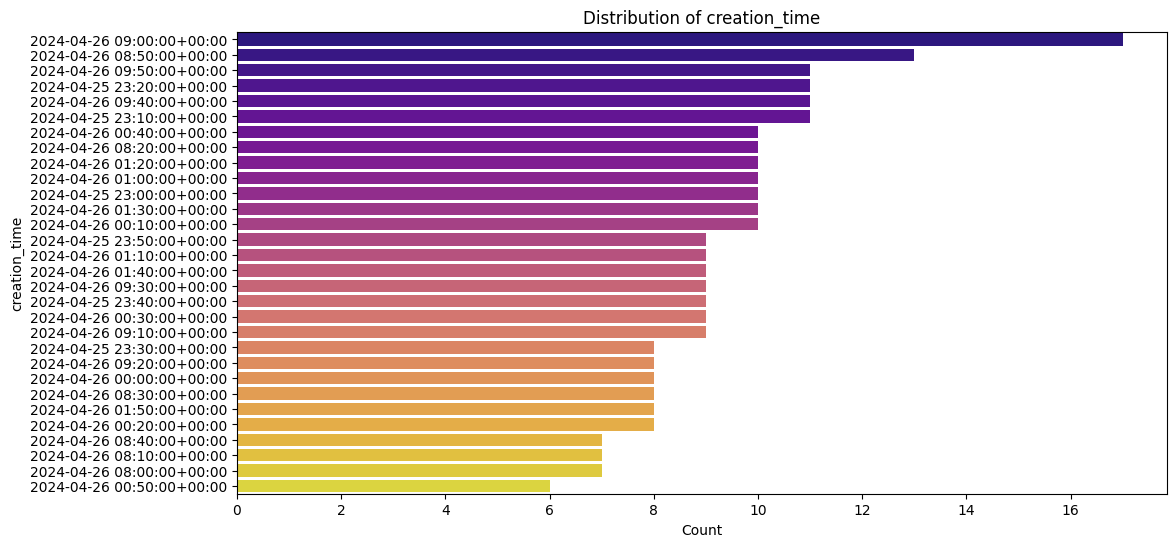


✔️ Unique Values in end_time:
end_time
2024-04-26 09:10:00+00:00    17
2024-04-26 09:00:00+00:00    13
2024-04-26 10:00:00+00:00    11
2024-04-25 23:30:00+00:00    11
2024-04-26 09:50:00+00:00    11
2024-04-25 23:20:00+00:00    11
2024-04-26 00:50:00+00:00    10
2024-04-26 08:30:00+00:00    10
2024-04-26 01:30:00+00:00    10
2024-04-26 01:10:00+00:00    10
2024-04-25 23:10:00+00:00    10
2024-04-26 01:40:00+00:00    10
2024-04-26 00:20:00+00:00    10
2024-04-26 00:00:00+00:00     9
2024-04-26 01:20:00+00:00     9
2024-04-26 01:50:00+00:00     9
2024-04-26 09:40:00+00:00     9
2024-04-25 23:50:00+00:00     9
2024-04-26 00:40:00+00:00     9
2024-04-26 09:20:00+00:00     9
2024-04-25 23:40:00+00:00     8
2024-04-26 09:30:00+00:00     8
2024-04-26 00:10:00+00:00     8
2024-04-26 08:40:00+00:00     8
2024-04-26 02:00:00+00:00     8
2024-04-26 00:30:00+00:00     8
2024-04-26 08:50:00+00:00     7
2024-04-26 08:20:00+00:00     7
2024-04-26 08:10:00+00:00     7
2024-04-26 01:00:00+00:00     6


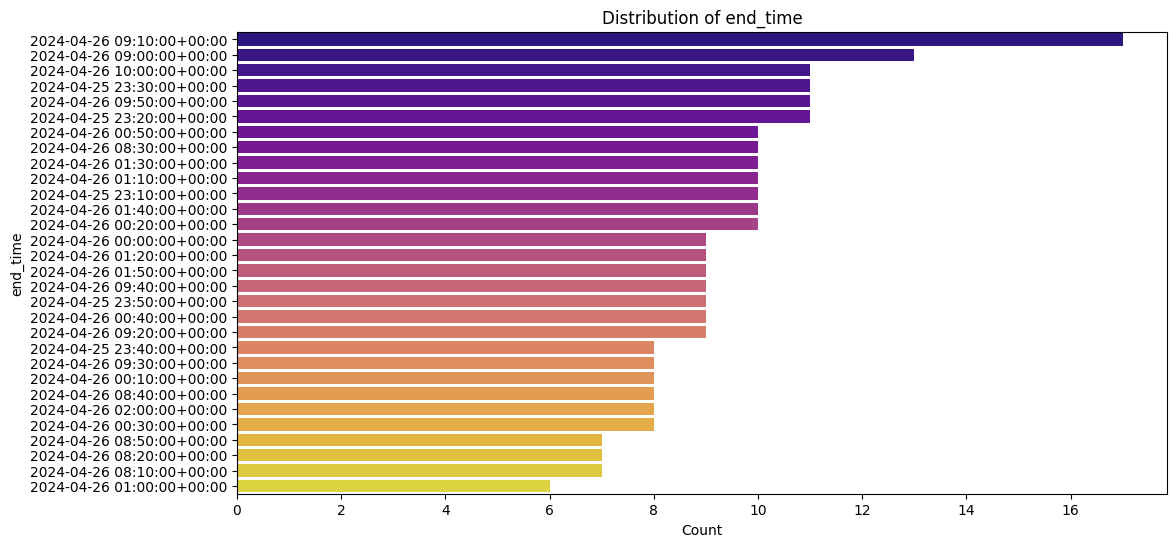


✔️ Unique Values in src_ip:
src_ip
165.225.209.4      29
165.225.26.101     28
155.91.45.242      28
136.226.67.101     28
147.161.131.1      21
165.225.240.79     18
136.226.77.103     17
147.161.161.82     16
165.225.212.255    15
94.188.248.74      14
136.226.64.114     13
165.225.33.6       12
136.226.80.97      11
165.225.213.7      11
165.225.8.79        6
192.241.230.19      2
65.49.1.69          2
198.235.24.81       1
65.49.1.72          1
65.49.1.94          1
65.49.1.104         1
65.49.1.97          1
65.49.1.99          1
65.49.1.76          1
65.49.1.96          1
65.49.1.95          1
65.49.1.74          1
192.241.205.18      1
Name: count, dtype: int64


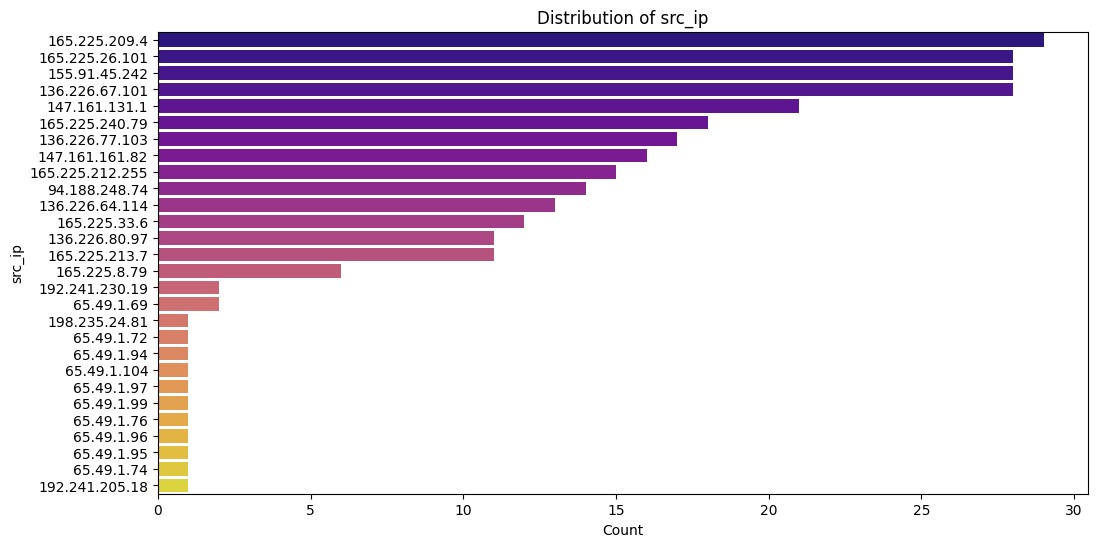


✔️ Unique Values in src_ip_country_code:
src_ip_country_code
US    113
CA     72
DE     28
AT     21
NL     18
AE     16
IL     14
Name: count, dtype: int64


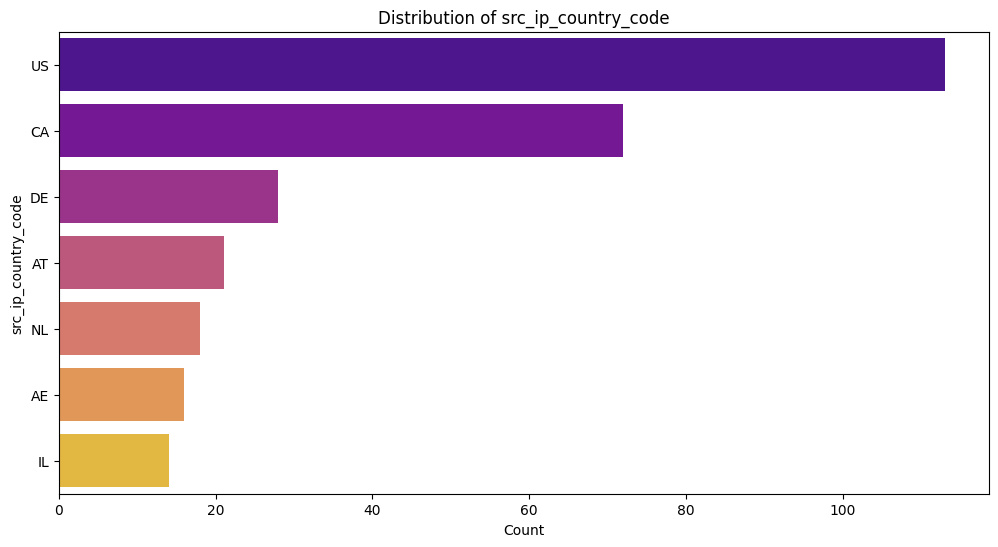


✔️ Unique Values in protocol:
protocol
HTTPS    282
Name: count, dtype: int64


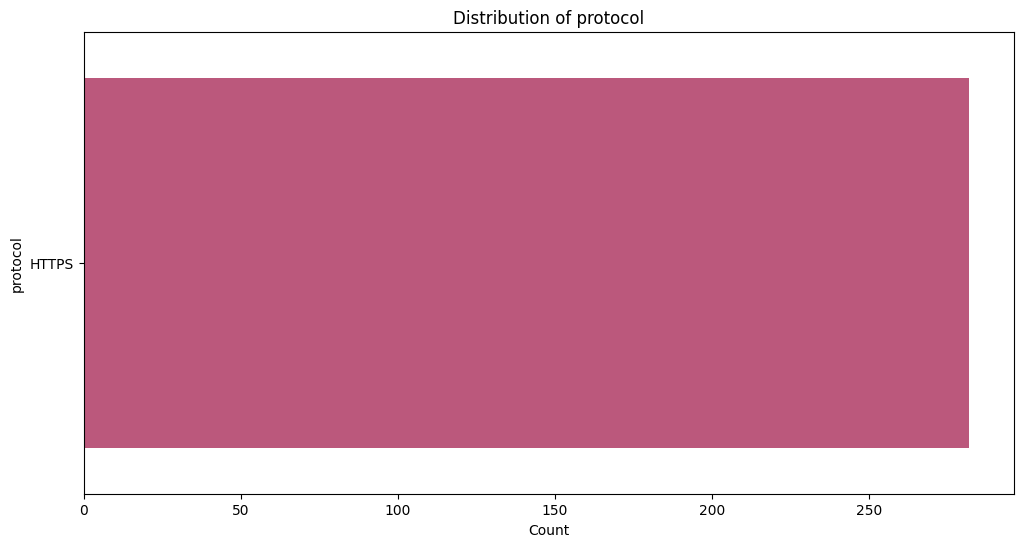


✔️ Unique Values in dst_ip:
dst_ip
10.138.69.97    282
Name: count, dtype: int64


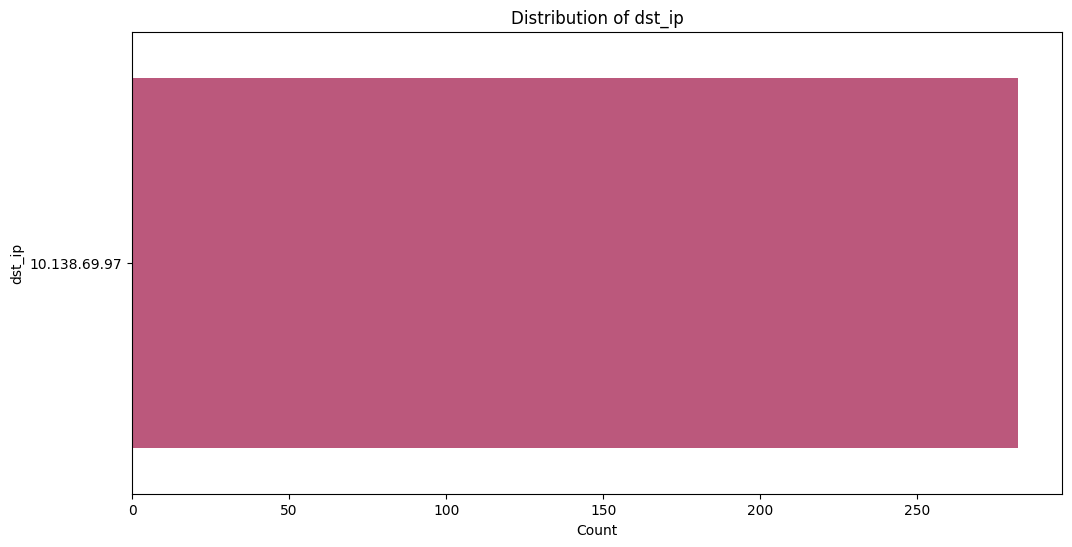


✔️ Unique Values in rule_names:
rule_names
Suspicious Web Traffic    282
Name: count, dtype: int64


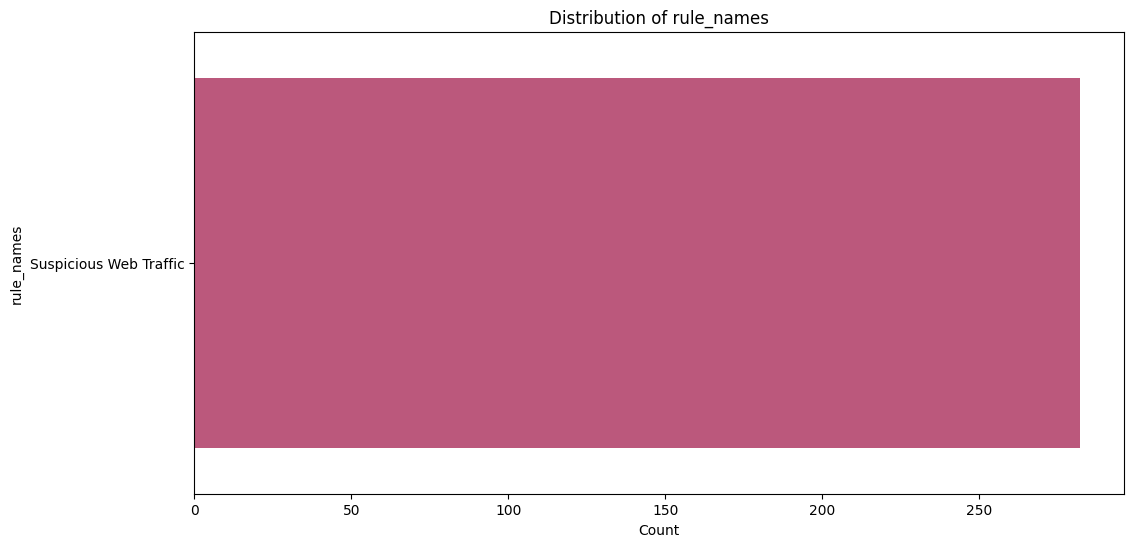


✔️ Unique Values in observation_name:
observation_name
Adversary Infrastructure Interaction    282
Name: count, dtype: int64


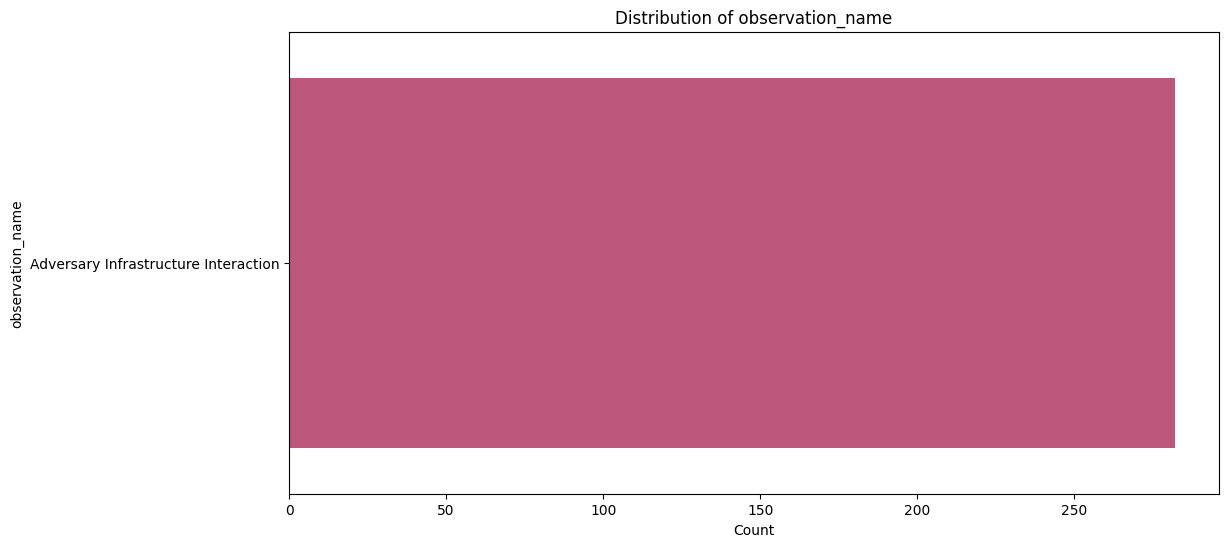


✔️ Unique Values in source.meta:
source.meta
AWS_VPC_Flow    282
Name: count, dtype: int64


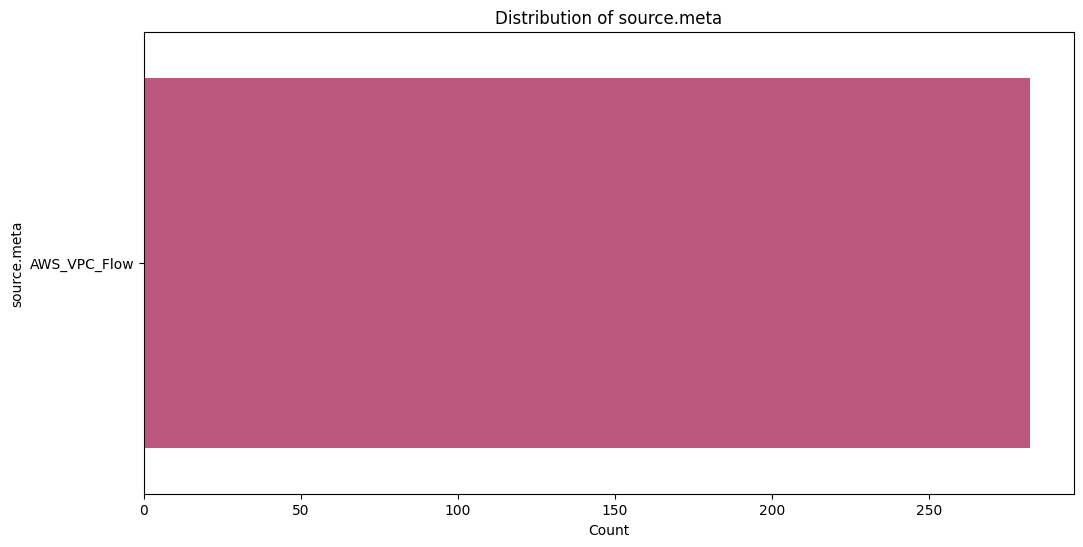


✔️ Unique Values in source.name:
source.name
prod_webserver    282
Name: count, dtype: int64


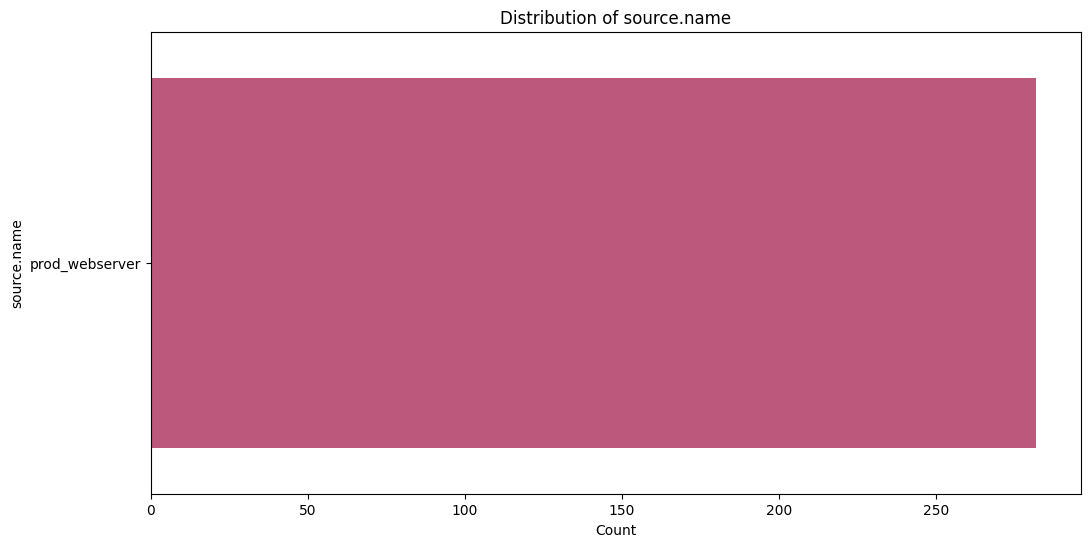


✔️ Unique Values in time:
time
2024-04-26 09:00:00+00:00    17
2024-04-26 08:50:00+00:00    13
2024-04-26 09:50:00+00:00    11
2024-04-25 23:20:00+00:00    11
2024-04-26 09:40:00+00:00    11
2024-04-25 23:10:00+00:00    11
2024-04-26 00:40:00+00:00    10
2024-04-26 08:20:00+00:00    10
2024-04-26 01:20:00+00:00    10
2024-04-26 01:00:00+00:00    10
2024-04-25 23:00:00+00:00    10
2024-04-26 01:30:00+00:00    10
2024-04-26 00:10:00+00:00    10
2024-04-25 23:50:00+00:00     9
2024-04-26 01:10:00+00:00     9
2024-04-26 01:40:00+00:00     9
2024-04-26 09:30:00+00:00     9
2024-04-25 23:40:00+00:00     9
2024-04-26 00:30:00+00:00     9
2024-04-26 09:10:00+00:00     9
2024-04-25 23:30:00+00:00     8
2024-04-26 09:20:00+00:00     8
2024-04-26 00:00:00+00:00     8
2024-04-26 08:30:00+00:00     8
2024-04-26 01:50:00+00:00     8
2024-04-26 00:20:00+00:00     8
2024-04-26 08:40:00+00:00     7
2024-04-26 08:10:00+00:00     7
2024-04-26 08:00:00+00:00     7
2024-04-26 00:50:00+00:00     6
Name: co

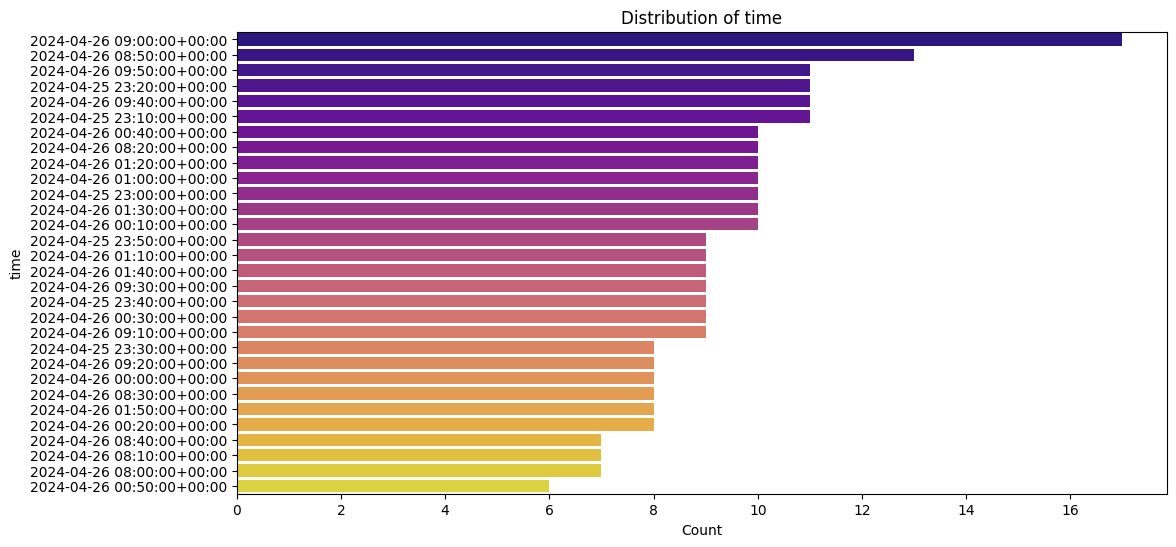


✔️ Unique Values in detection_types:
detection_types
waf_rule    282
Name: count, dtype: int64


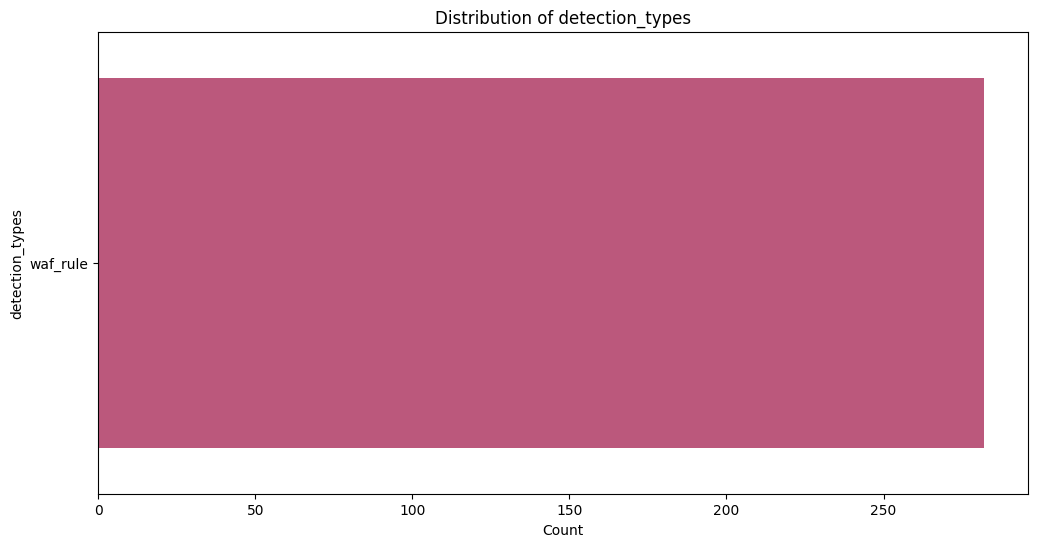

In [26]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"\n✔️ Unique Values in {col}:")
    print(df[col].value_counts())

    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette="plasma")
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()


✔️ Feature: traffic_intensity_log
   Skewness: 2.120 (Distribution asymmetry)
   Kurtosis: 6.588 (Tail heaviness)


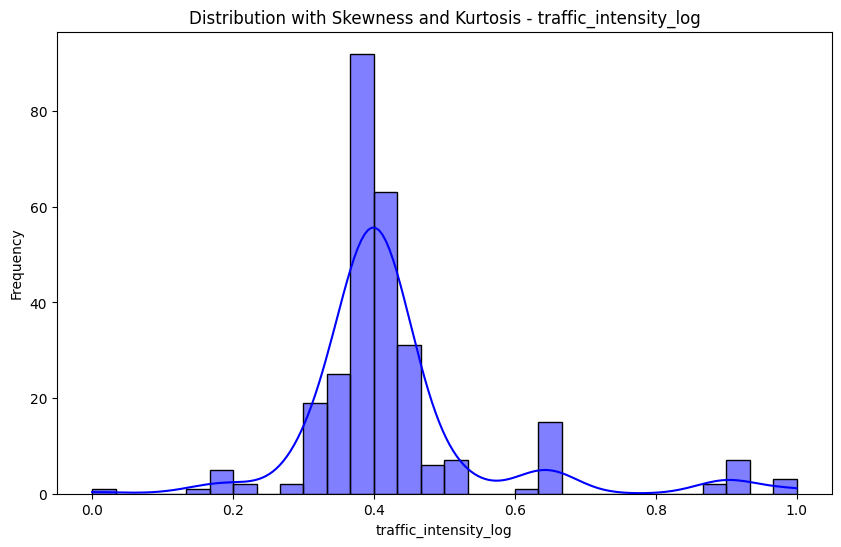


✔️ Feature: bytes_in_log
   Skewness: 3.922 (Distribution asymmetry)
   Kurtosis: 14.997 (Tail heaviness)


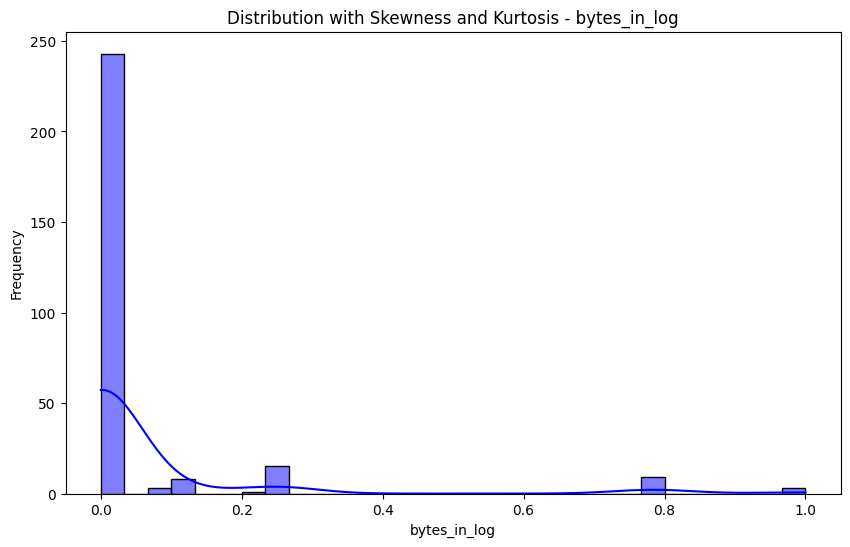


✔️ Feature: src_ip_encoded
   Skewness: 1.453 (Distribution asymmetry)
   Kurtosis: 2.145 (Tail heaviness)


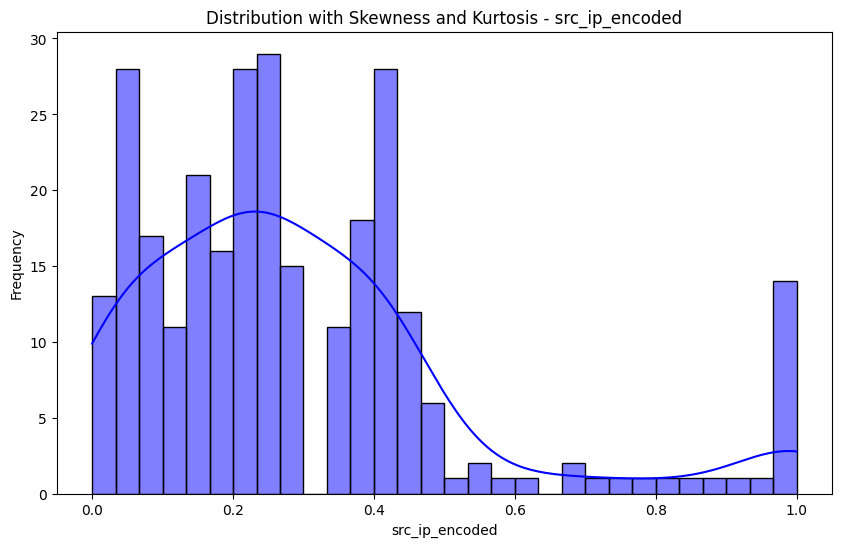


✔️ Feature: src_ip_country_code_encoded
   Skewness: -0.219 (Distribution asymmetry)
   Kurtosis: -1.468 (Tail heaviness)


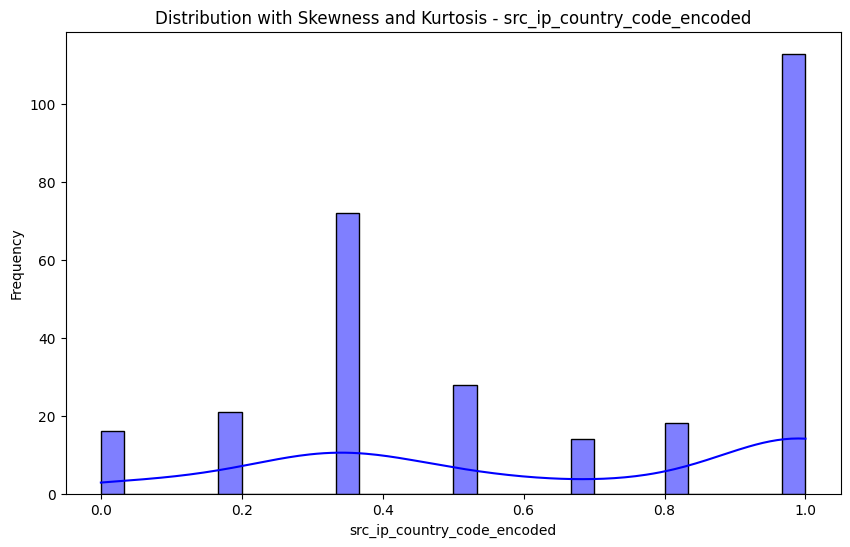

In [27]:
from scipy.stats import skew, kurtosis

for col in numerical_columns:
    col_skew = skew(df[col].dropna())
    col_kurt = kurtosis(df[col].dropna())
    print(f"\n✔️ Feature: {col}")
    print(f"   Skewness: {col_skew:.3f} (Distribution asymmetry)")
    print(f"   Kurtosis: {col_kurt:.3f} (Tail heaviness)")

    # Histogram and KDE plot
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution with Skewness and Kurtosis - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Feature Engineering

In [28]:
 
# Example: Creating a duration feature if time columns exist
if 'creation_time' in df.columns and 'end_time' in df.columns:
    df['creation_time'] = pd.to_datetime(df['creation_time'])
    df['end_time'] = pd.to_datetime(df['end_time'])
    df['connection_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
    print("✔️ New feature 'connection_duration' created.")

✔️ New feature 'connection_duration' created.


In [29]:
# Encoding categorical variables
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[f'{col}_encoded'] = LabelEncoder().fit_transform(df[col])
    print(f"✔️ Categorical feature '{col}' encoded.")

✔️ Categorical feature 'src_ip' encoded.
✔️ Categorical feature 'src_ip_country_code' encoded.
✔️ Categorical feature 'protocol' encoded.
✔️ Categorical feature 'dst_ip' encoded.
✔️ Categorical feature 'rule_names' encoded.
✔️ Categorical feature 'observation_name' encoded.
✔️ Categorical feature 'source.meta' encoded.
✔️ Categorical feature 'source.name' encoded.
✔️ Categorical feature 'time' encoded.
✔️ Categorical feature 'detection_types' encoded.


In [30]:
print("\n✔️Final Dataset Features:")
print(df.columns)

print("\n✅ Final Dataset Shape:", df.shape)


✔️Final Dataset Features:
Index(['creation_time', 'end_time', 'src_ip', 'src_ip_country_code',
       'protocol', 'dst_ip', 'rule_names', 'observation_name', 'source.meta',
       'source.name', 'time', 'detection_types', 'traffic_intensity_log',
       'bytes_in_log', 'src_ip_encoded', 'src_ip_country_code_encoded',
       'connection_duration', 'protocol_encoded', 'dst_ip_encoded',
       'rule_names_encoded', 'observation_name_encoded', 'source.meta_encoded',
       'source.name_encoded', 'time_encoded', 'detection_types_encoded'],
      dtype='object')

✅ Final Dataset Shape: (282, 25)


In [31]:
# Proceed to splitting the dataset into training and testing sets for model training.
print("\n✔️ Feature engineering completed! Ready for model training.")


✔️ Feature engineering completed! Ready for model training.


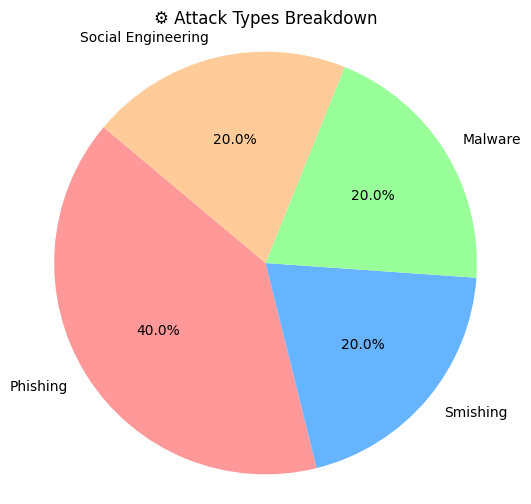

In [32]:
import matplotlib.pyplot as plt

# Example mock data based on analysis (you can later extract this dynamically)
attack_types = ['Phishing', 'Smishing', 'Malware', 'Social Engineering']
attack_counts = [2, 1, 1, 1]  # You can adjust these as per output

# Pie Chart for Attack Types
plt.figure(figsize=(6,6))
plt.pie(attack_counts, labels=attack_types, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('\u2699 Attack Types Breakdown')  # Unicode for ⚙️ Gear emoji
plt.axis('equal')
plt.show()

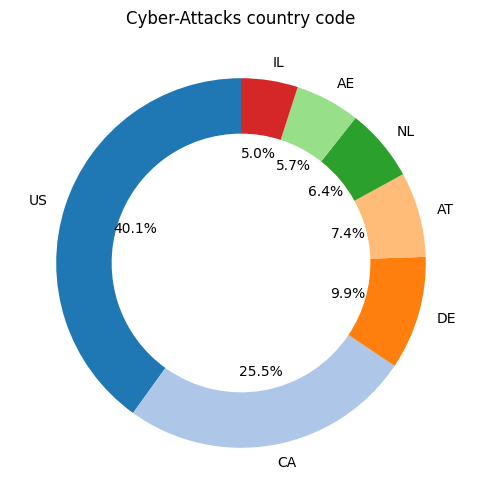

In [33]:
attack_counts = df['src_ip_country_code'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.3}, colors=plt.cm.tab20.colors)
plt.title('Cyber-Attacks country code')
plt.show()

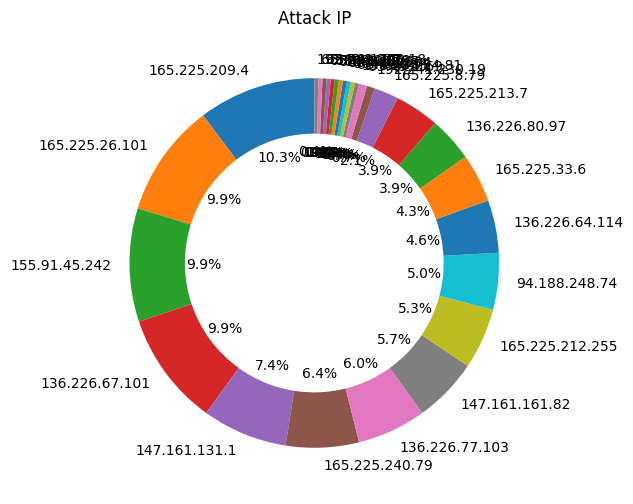

In [34]:
severity_counts = df['src_ip'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.3})
plt.title('Attack IP')
plt.show()

# Conclusion

**1. AI-Powered Threat Detection**
- Machine Learning Models: AI can analyze large volumes of network traffic, user behaviors, and system activities in real time to detect unusual patterns that might signal an attack. These models can learn from historical attack data to recognize sophisticated threats like zero-day exploits or advanced persistent threats (APTs).

- Anomaly Detection: Through unsupervised learning, AI can detect anomalies in network traffic, user activity, or application behavior that deviate from established baselines. This helps to identify threats even before they fully manifest.

- Signature-based Detection: AI can enhance traditional signature-based systems by applying advanced pattern recognition and natural language processing to detect subtle changes that could signify a breach.

**2. AI for Automated Incident Response**
- Automated Response Systems: AI can autonomously trigger actions in response to detected threats, such as isolating affected systems, blocking malicious IPs, or rolling back changes in real time. This reduces human intervention time and can quickly contain damage.

- Playbook Automation: Security orchestration automation and response (SOAR) platforms can be augmented with AI to follow a decision-making process based on past incidents, creating custom playbooks that adapt to new threats.

**3. Predictive Capabilities**
- Threat Intelligence: AI can analyze data from various sources (e.g., threat intelligence feeds, dark web, social media, etc.) to identify emerging threats. AI models can predict which vulnerabilities are likely to be exploited based on ongoing attack patterns.

- Vulnerability Management: AI can prioritize vulnerabilities by considering the likelihood of exploitation and potential impact, helping security teams focus on what matters most.

**4. Behavioral Analytics**
- User and Entity Behavior Analytics (UEBA): AI can monitor the behavior of users, devices, and applications. If any entity begins to act in a way that deviates from its normal behavior (e.g., accessing files they normally wouldn’t), it can be flagged as a potential insider threat or compromised account.

- Biometric and Access Controls: AI can further strengthen access controls by using biometric data (face recognition, voice authentication) and behavioral biometrics (typing patterns, mouse movements) for continuous authentication.

**5. AI-Driven Phishing Detection**
- Email Filtering and URL Scanning: AI can evaluate incoming emails and URLs for patterns typically associated with phishing attempts (e.g., lookalike domains, unusual sender patterns, content analysis).

- Natural Language Processing (NLP): Using NLP, AI can also assess email content for signs of social engineering or malicious intent, flagging suspicious communications before they reach users.

**6. Deception Technologies**
- AI-Powered Honeypots: AI can help create deceptive environments that lure attackers away from valuable assets. These “honeypots” simulate vulnerable systems to trap hackers, while AI continually adapts to the evolving tactics of attackers.

**7. Advanced Malware Analysis**
- Dynamic Analysis: AI can analyze suspicious files and behaviors in real-time, allowing for the detection of malware that changes or evolves. Through sandboxing and machine learning, AI can identify novel or polymorphic malware that traditional signature-based systems might miss.

- Heuristic and Static Analysis: AI can scan files, code, and applications for signs of potentially malicious behavior or known malware characteristics, even before execution.

**8. AI for Secure DevOps (DevSecOps)**
- Automated Code Reviews: AI can automatically scan code for security vulnerabilities before it’s pushed to production, identifying things like SQL injection risks, cross-site scripting (XSS), or other potential attack vectors.

- CI/CD Integration: AI can be integrated into Continuous Integration/Continuous Deployment pipelines to ensure that security is embedded in the development process rather than being an afterthought.

**9. Advanced Encryption and Privacy Preservation**
- Homomorphic Encryption: AI can assist in developing privacy-preserving techniques like homomorphic encryption, which allows data to be processed while still encrypted, ensuring privacy even during computations.

- Privacy-Aware Machine Learning: AI can also be used to ensure that privacy is maintained throughout data usage and processing, without compromising security.

**Challenges and Considerations**
- False Positives: One of the risks with AI in cybersecurity is the potential for false positives. While AI models are getting better, they can sometimes flag legitimate activities as threats, causing unnecessary alarm.

- Data Privacy Concerns: AI requires vast amounts of data to be effective, which may raise privacy concerns. Ensuring that the data used for training AI models complies with privacy regulations (GDPR, CCPA) is critical.

- Adversarial AI: Hackers can attempt to deceive AI models using adversarial attacks, where they intentionally manipulate input data to mislead AI-based systems. Constant adaptation of AI models is necessary to combat this threat.

**Leading AI Technologies in Cybersecurity**
- Darktrace: Known for its self-learning AI that detects and responds to cyber threats in real-time.

- Cylance: Uses AI to prevent malware infections by analyzing file behavior.

- Sophos Intercept X: Combines deep learning AI and behavioral analysis to prevent malware.

- CrowdStrike: Utilizes machine learning and AI for endpoint protection and threat intelligence.

**The Future of AI in Cybersecurity**
- As AI continues to evolve, its role in cybersecurity will expand, offering new tools to combat increasingly sophisticated attacks. The ability of AI to process vast amounts of data and adapt to new threats makes it a powerful ally in the fight against cybercrime.